# E2.2 — Convergence Analysis (start-point ergodicity test)

Tests whether the diverse-start extended replicates of a system relax into the **same**
equilibrated ensemble, or stay trapped near their starting conformations. This is the
ergodicity check that decides whether the leaner campaign holds.

**Inputs.** All `trajectories_extended/{SYSTEM}_*ns_{start}_r*` runs found on disk (currently
the compact/extended pair; mid/open fold in automatically when run).

**What it compares.** Radius of gyration is the primary coordinate — the starts differ on it by
construction, so its convergence is the direct ergodicity signal. Motif SASA is the reported
observable and the downstream consequence. For each it reports, on the equilibrated portion:
the autocorrelation-corrected mean ± CI (N_eff-based, reusing the E1.3 estimator), a
standardised mean difference z between starts, and the distribution overlap coefficient. The
cumulative-mean-versus-time traces show whether the starts trend toward a common value (mixing)
or plateau apart (trapping) — these are less sensitive to the small N_eff than any single
statistic, so treat the plots as the real arbiter.

**Verdict (operationalised guide, not gospel given the limited N_eff per run):**
- **CONVERGED** — means consistent (|z| < 2) and distributions overlap well (OVL > 0.7) on both
  observables → ergodic; pool diverse starts, leaner campaign proceeds.
- **DIVERGED** — clearly separated means (|z| > 3) or poor overlap (OVL < 0.5) on either →
  trapped; length will not fix it (diverse-start ensemble w/ population caveat, or enhanced
  sampling, or lead with local mechanistic observables).
- **AMBIGUOUS** — in between → add the mid/open replicates and re-assess pooled stability.

## 1 — Imports
**Out:** namespace.

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt

print(f"MDTraj {md.__version__}")

MDTraj 1.11.1


## 2 — Configuration
**Out:** parameters and verdict thresholds.

In [3]:
SYSTEM = "YIY_reline"
EQUIL_DISCARD_NS = 20.0          # scaled to glyceline tau_int
STRIDE           = 10            # analyse every 10 ps (resolves ns correlations, keeps SASA tractable)
SAVE_INTERVAL_PS = 1.0

Z_CONSISTENT = 2.0               # |z| below -> means consistent
Z_SEPARATED  = 3.0               # |z| above -> means clearly separated
OVL_GOOD     = 0.70              # overlap above -> distributions agree
OVL_POOR     = 0.50              # overlap below -> distributions separated

THREE_TO_ONE = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E',
                'GLY':'G','HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F',
                'PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'}

## 3 — Autocorrelation estimator
Same validated FFT/Sokal estimator used in E1.3; here it supplies N_eff for the corrected
standard errors. **Out:** `integrated_time`.

In [4]:
def autocorr_func_1d(x):
    x = np.asarray(x, float); x = x - x.mean()
    n = len(x); nfft = 1
    while nfft < 2 * n:
        nfft *= 2
    f = np.fft.fft(x, n=nfft)
    acf = np.fft.ifft(f * np.conjugate(f))[:n].real
    acf /= acf[0]
    return acf

def integrated_time(x, c=5.0):
    taus = 2.0 * np.cumsum(autocorr_func_1d(x)) - 1.0
    m = np.arange(len(taus)) < c * taus
    w = int(np.argmin(m)) if np.any(m) else len(taus) - 1
    return max(taus[w], 1.0)

## 4 — Discover extended-campaign runs
Globs the extended trajectory tree for this system. **Out:** `RUNS` (label -> paths).

In [5]:
PROJECT_DIR = Path("~/des-peptide-study").expanduser()
PRMTOP      = next(p for p in (PROJECT_DIR/"systems"/SYSTEM/f"{SYSTEM}.prmtop",
                               PROJECT_DIR/"systems"/f"{SYSTEM}.prmtop") if p.exists())
EXT_DIR     = PROJECT_DIR / "extension" / "trajectories_extended"

pat = re.compile(rf"{re.escape(SYSTEM)}_(\d+)ns_(.+)_r(\d+)$")
RUNS = {}
for d in sorted(EXT_DIR.glob(f"{SYSTEM}_*")):
    m = pat.match(d.name)
    dcd = d / f"{d.name}.dcd"
    if m and dcd.exists():
        RUNS[m.group(2)] = {"tag": d.name, "dcd": dcd, "ns": int(m.group(1))}

print(f"{len(RUNS)} extended run(s) for {SYSTEM}:")
for label, r in RUNS.items():
    print(f"  {label:<9} {r['tag']} ({r['ns']} ns)")
assert len(RUNS) >= 2, "need at least two starts to test convergence"

3 extended run(s) for YIY_reline:
  compact   YIY_reline_200ns_compact_r1 (200 ns)
  extended  YIY_reline_200ns_extended_r1 (200 ns)
  mid       YIY_reline_200ns_mid_r1 (200 ns)


## 5 — Extract observables
Loads each run strided, computes peptide Rg and motif SASA per frame, and splits off the
equilibrated portion. **In:** `RUNS`. **Out:** `data` (label -> series).

In [6]:
motif_seq = SYSTEM.split("_")[0]
dt_ps     = SAVE_INTERVAL_PS * STRIDE
n_equil   = int(EQUIL_DISCARD_NS * 1000.0 / dt_ps)

def observables(dcd):
    traj = md.load(str(dcd), top=str(PRMTOP), stride=STRIDE)
    sel = traj.topology.select("protein")
    if len(sel) == 0:
        sel = traj.topology.select("not (water or resname HOH WAT CHO CLA URE GOL NA CL Na+ Cl-)")
    prot = traj.atom_slice(sel)
    seq = "".join(THREE_TO_ONE.get(r.name, "X") for r in prot.topology.residues)
    pos = seq.find(motif_seq); idx = list(range(pos, pos + len(motif_seq)))
    sasa = md.shrake_rupley(prot, mode="residue")[:, idx].sum(axis=1)
    rg = md.compute_rg(prot)
    return rg, sasa

data = {}
for label, r in RUNS.items():
    print(f"  {label} ...", end=" ", flush=True)
    rg, sasa = observables(r["dcd"])
    data[label] = {"rg_full": rg, "sasa_full": sasa,
                   "rg": rg[n_equil:], "sasa": sasa[n_equil:]}
    print(f"{len(rg)} frames")
print("done")

  compact ... 20000 frames
  extended ... 20000 frames
  mid ... 20000 frames
done


## 6 — Per-start statistics
Equilibrated mean, τ_int, N_eff, and N_eff-based 95% CI for each start and observable.
**Out:** `stats` table.

In [7]:
def stat(series):
    n = len(series); tau = integrated_time(series)
    n_eff = n / tau
    se = series.std(ddof=1) / np.sqrt(n_eff)
    return {"mean": float(series.mean()), "tau_int_ns": tau * dt_ps / 1000.0,
            "N_eff": n_eff, "se": float(se), "ci95": 1.96 * float(se)}

rows = []
for label in RUNS:
    for obs in ("rg", "sasa"):
        s = stat(data[label][obs])
        rows.append({"start": label, "observable": obs.upper(),
                     "mean": round(s["mean"], 4), "tau_int_ns": round(s["tau_int_ns"], 2),
                     "N_eff": round(s["N_eff"], 1), "ci95": round(s["ci95"], 4)})
        data[label].setdefault("stat", {})[obs] = s
stats = pd.DataFrame(rows)
print(stats.to_string(index=False))

   start observable   mean  tau_int_ns  N_eff   ci95
 compact         RG 0.6303        4.31   41.7 0.0098
 compact       SASA 5.3236        4.73   38.1 0.0907
extended         RG 0.6802       10.65   16.9 0.0215
extended       SASA 5.4800        4.71   38.2 0.1177
     mid         RG 0.6748        4.91   36.6 0.0141
     mid       SASA 5.5503        4.69   38.4 0.1118


## 7 — Pairwise comparison
Standardised mean difference z = |Δmean| / √(SE₁²+SE₂²) and distribution overlap for each pair
and observable. **Out:** `comp` table.

In [8]:
def overlap(a, b, bins=50):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    edges = np.linspace(lo, hi, bins + 1); bw = edges[1] - edges[0]
    ha, _ = np.histogram(a, bins=edges, density=True)
    hb, _ = np.histogram(b, bins=edges, density=True)
    return float(np.sum(np.minimum(ha, hb)) * bw)

labels = list(RUNS)
crows = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        A, B = labels[i], labels[j]
        for obs in ("rg", "sasa"):
            sa, sb = data[A]["stat"][obs], data[B]["stat"][obs]
            z = abs(sa["mean"] - sb["mean"]) / np.sqrt(sa["se"]**2 + sb["se"]**2)
            ovl = overlap(data[A][obs], data[B][obs])
            crows.append({"pair": f"{A} vs {B}", "observable": obs.upper(),
                          "delta_mean": round(sa["mean"] - sb["mean"], 4),
                          "z": round(z, 2), "overlap": round(ovl, 2)})
comp = pd.DataFrame(crows)
print(comp.to_string(index=False))

               pair observable  delta_mean    z  overlap
compact vs extended         RG     -0.0499 4.15     0.53
compact vs extended       SASA     -0.1564 2.06     0.76
     compact vs mid         RG     -0.0445 5.09     0.50
     compact vs mid       SASA     -0.2267 3.09     0.71
    extended vs mid         RG      0.0054 0.41     0.78
    extended vs mid       SASA     -0.0703 0.85     0.91


## 7b — Pooled-ensemble stability
Pools the equilibrated series across all starts (equal frame weight; runs are equal length) and
reports the autocorrelation-corrected pooled mean ± CI from the summed per-start N_eff. The
leave-one-out table drops each start in turn, so a shift larger than the pooled CI flags a start
that dominates the mean (e.g. a trapped or under-sampled one). Comparing the pooled mean across
re-runs as starts are added shows whether the newest start still moves it. **Out:** `pooled_stats`,
`loo`.

In [9]:
pool_rows, loo_rows = [], []
for obs in ("rg", "sasa"):
    series_all = {lab: data[lab][obs] for lab in RUNS}
    pooled = np.concatenate(list(series_all.values()))
    neff_sum = sum(data[lab]["stat"][obs]["N_eff"] for lab in RUNS)
    pooled_mean = float(pooled.mean())
    pooled_ci = 1.96 * pooled.std(ddof=1) / np.sqrt(neff_sum)
    pool_rows.append({"observable": obs.upper(), "n_starts": len(RUNS),
                      "pooled_mean": round(pooled_mean, 4),
                      "N_eff_pooled": round(neff_sum, 1), "ci95": round(float(pooled_ci), 4)})
    for drop in RUNS:
        rest = [series_all[lab] for lab in RUNS if lab != drop]
        m_rest = float(np.concatenate(rest).mean())
        loo_rows.append({"observable": obs.upper(), "dropped": drop,
                         "mean_without": round(m_rest, 4),
                         "shift": round(m_rest - pooled_mean, 4),
                         "shift_gt_ci": bool(abs(m_rest - pooled_mean) > pooled_ci)})
pooled_stats = pd.DataFrame(pool_rows)
loo = pd.DataFrame(loo_rows)
print(pooled_stats.to_string(index=False)); print()
print(loo.to_string(index=False)); print()
for obs in ("RG", "SASA"):
    ci = float(pooled_stats.loc[pooled_stats.observable == obs, "ci95"].iloc[0])
    mx = float(loo.loc[loo.observable == obs, "shift"].abs().max())
    print(f"{obs}: max leave-one-out shift {mx:.4f} vs pooled CI {ci:.4f} -> "
          f"{'robust to any single start' if mx <= ci else 'DOMINATED by one start'}")

observable  n_starts  pooled_mean  N_eff_pooled   ci95
        RG         3       0.6618          95.3 0.0093
      SASA         3       5.4513         114.7 0.0644

observable  dropped  mean_without   shift  shift_gt_ci
        RG  compact        0.6775  0.0157         True
        RG extended        0.6525 -0.0092        False
        RG      mid        0.6553 -0.0065        False
      SASA  compact        5.5152  0.0638        False
      SASA extended        5.4370 -0.0143        False
      SASA      mid        5.4018 -0.0495        False

RG: max leave-one-out shift 0.0157 vs pooled CI 0.0093 -> DOMINATED by one start
SASA: max leave-one-out shift 0.0638 vs pooled CI 0.0644 -> robust to any single start


## 8 — Distributions and cumulative-mean traces
Left: equilibrated Rg and SASA distributions per start. Right: cumulative mean from t=0 with the
equilibration cut marked — converging traces indicate mixing, plateaus apart indicate trapping.
**Out:** figure.

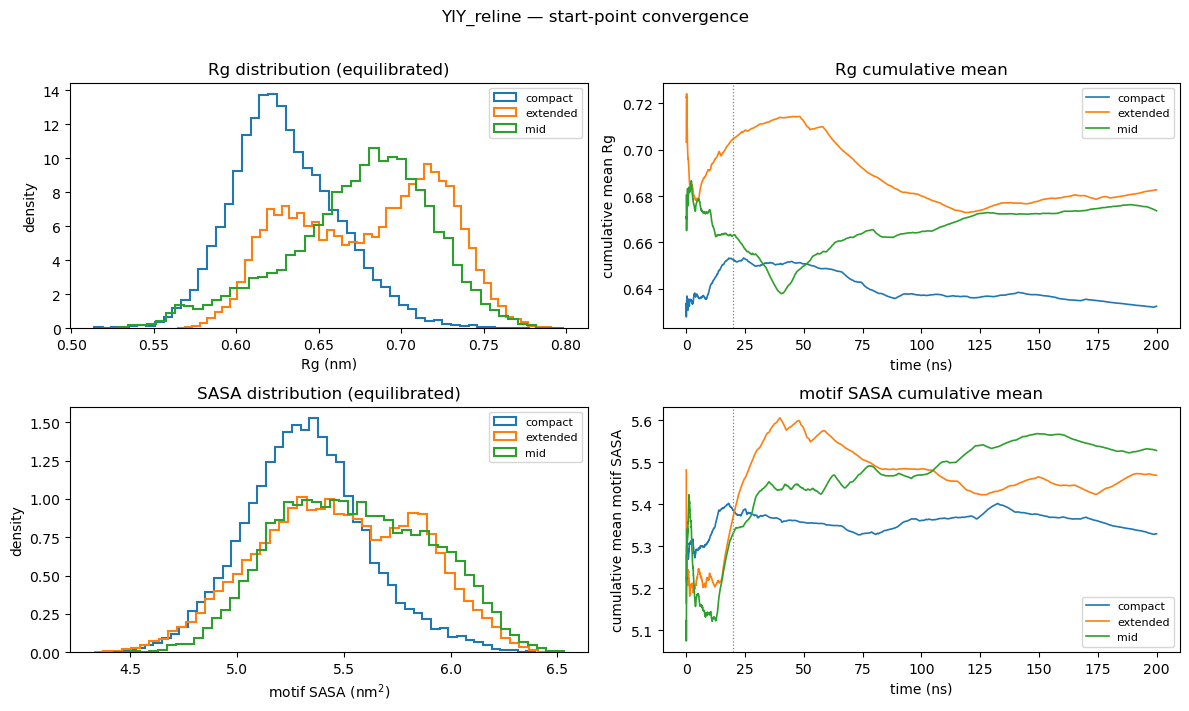

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
for label in RUNS:
    d = data[label]
    ax[0,0].hist(d["rg"], bins=50, density=True, histtype="step", lw=1.5, label=label)
    ax[1,0].hist(d["sasa"], bins=50, density=True, histtype="step", lw=1.5, label=label)
    for k, (obs, axc) in enumerate((("rg_full", ax[0,1]), ("sasa_full", ax[1,1]))):
        s = d[obs]; cum = np.cumsum(s) / np.arange(1, len(s) + 1)
        t = np.arange(len(s)) * dt_ps / 1000.0
        axc.plot(t, cum, lw=1.2, label=label)

ax[0,0].set_xlabel("Rg (nm)"); ax[0,0].set_ylabel("density"); ax[0,0].set_title("Rg distribution (equilibrated)")
ax[1,0].set_xlabel("motif SASA (nm$^2$)"); ax[1,0].set_ylabel("density"); ax[1,0].set_title("SASA distribution (equilibrated)")
for axc, name in ((ax[0,1], "Rg"), (ax[1,1], "motif SASA")):
    axc.axvline(EQUIL_DISCARD_NS, color="grey", ls=":", lw=0.9)
    axc.set_xlabel("time (ns)"); axc.set_ylabel(f"cumulative mean {name}")
    axc.set_title(f"{name} cumulative mean")
for a in ax.flat:
    a.legend(fontsize=8)
fig.suptitle(f"{SYSTEM} — start-point convergence", y=1.01)
fig.tight_layout()
OUT = PROJECT_DIR / "extension" / "analysis" / "convergence"
OUT.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT / f"{SYSTEM}_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 — Verdict
Applies the thresholds to the compact-vs-extended contrast (the designed pair). The plots above
remain the arbiter where the call is borderline. **Out:** verdict + `convergence_summary_{SYSTEM}.csv`.

In [11]:
def classify(zr, zs, ovr, ovs):
    if zr < Z_CONSISTENT and zs < Z_CONSISTENT and ovr > OVL_GOOD and ovs > OVL_GOOD:
        return "CONVERGED"
    if zr > Z_SEPARATED or zs > Z_SEPARATED or ovr < OVL_POOR or ovs < OVL_POOR:
        return "DIVERGED"
    return "AMBIGUOUS"

REC = {
 "CONVERGED": "Ergodic at 200 ns. Pool the diverse starts as one ensemble; the leaner campaign "
              "holds. Proceed to the remaining glyceline systems, the reline probe, and water "
              "top-ups. Start-point independence is a reportable strength.",
 "DIVERGED":  "Trapped at 200 ns; more brute length will not fix it. Options: (a) diverse-start "
              "ensemble with an explicit caveat that basin populations are not equilibrium; "
              "(b) enhanced sampling (REMD / metadynamics on Rg) -> Paper 2; (c) lead with local "
              "mechanistic observables (coordination, H-bonds) and report SASA with the caveat.",
 "AMBIGUOUS": "Borderline. Run the mid and open starts and re-assess whether the pooled ensemble "
              "stabilises (the 4th start no longer shifts it) before committing the campaign.",
}

if "compact" in RUNS and "extended" in RUNS:
    sub = comp[comp["pair"] == "compact vs extended"].set_index("observable")
    zr, zs = sub.loc["RG","z"], sub.loc["SASA","z"]
    ovr, ovs = sub.loc["RG","overlap"], sub.loc["SASA","overlap"]
    v = classify(zr, zs, ovr, ovs)
    print(f"compact vs extended -> Rg: z={zr:.2f}, OVL={ovr:.2f} | SASA: z={zs:.2f}, OVL={ovs:.2f}")
    print(f"\nVERDICT: {v}\n{REC[v]}")
else:
    print("compact/extended pair not both present; see pairwise table above.")
    v = "PENDING"

comp.to_csv(OUT / f"convergence_summary_{SYSTEM}.csv", index=False)
print("\nsaved:", OUT / f"convergence_summary_{SYSTEM}.csv")

compact vs extended -> Rg: z=4.15, OVL=0.53 | SASA: z=2.06, OVL=0.76

VERDICT: DIVERGED
Trapped at 200 ns; more brute length will not fix it. Options: (a) diverse-start ensemble with an explicit caveat that basin populations are not equilibrium; (b) enhanced sampling (REMD / metadynamics on Rg) -> Paper 2; (c) lead with local mechanistic observables (coordination, H-bonds) and report SASA with the caveat.

saved: /Users/rossgibson/des-peptide-study/extension/analysis/convergence/convergence_summary_YIY_reline.csv
